In [1]:
# path to user functions
import sys  
sys.path.append('../Src/')

from platform import python_version

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import importlib 

# import user functions
import UserUtilityFunctions as uf
import UserStatisticalFunctions as usf
import UserVisualization as uv

# set seaborn theme
sns.set_theme()

# print versions
print("Numpy Version: " + np.__version__)
print("Pandas Version: " + pd.__version__)
print("Seaborn Version: " + sns.__version__)
print("Matplotlib Version: " + plt.matplotlib.__version__)
print("Python Version: " + python_version())

# adjust pandas display options to max
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# adjust pandas display options to ensure full display of content
pd.set_option('display.max_colwidth', None)

Numpy Version: 1.26.4
Pandas Version: 2.2.3
Seaborn Version: 0.13.2
Matplotlib Version: 3.9.2
Python Version: 3.9.20


### Import Data

In [2]:
# import data
df = pd.read_pickle("../Data/Version2_Heart_2V2.pkl")
df_label = pd.read_pickle("../Data/Version2_Label_2V2.pkl")
df_can = pd.read_pickle("../Data/Version2_CAN_2V2.pkl")
df_don = pd.read_pickle("../Data/Version2_DON_2V2.pkl")
df_drop = pd.read_pickle("../Data/Version2_DROP_2V2.pkl")
df_both = pd.read_pickle("../Data/Version2_Both_2V2.pkl")
df_nominal = pd.read_pickle("../Data/Version2_Nominal_2V2.pkl")
df_ordinal = pd.read_pickle("../Data/Version2_Ordinal_2V2.pkl")
df_numeric = pd.read_pickle("../Data/Version2_Numeric_2V2.pkl")
df_object = pd.read_pickle("../Data/Version2_Object_2V2.pkl")
df_unknown = pd.read_pickle("../Data/Version2_Unknow_2V2.pkl")
df_date = pd.read_pickle("../Data/Version2_Date_2V2.pkl")
df_dict = pd.read_pickle("../Data/Version2_Dictionary_2V2.pkl")

# checking for duplicated column name
df.columns[df.columns.duplicated()]

Index([], dtype='object')

In [3]:
print(f"Heart Dataset Rows: {df.shape[0]:,} & Columns: {df.shape[1]:,}")
print(f"Label Features: {df_label.shape[0]:,}")
print(f"Candidate Features: {df_can.shape[0]:,}")
print(f"Donor Features: {df_don.shape[0]:,}")
print(f"Date Features: {df_date.shape[0]:,}")
print(f"Both Features: {df_both.shape[0]:,}")
print(f"Unknown Features: {df_unknown.shape[0]:,}")
print(f"Object Features: {df_object.shape[0]:,}")
print(f"Removed Features: {df_drop.shape[0]:,}")

Heart Dataset Rows: 27,494 & Columns: 306
Label Features: 14
Candidate Features: 9
Donor Features: 102
Date Features: 14
Both Features: 9
Unknown Features: 16
Object Features: 11
Removed Features: 26


In [4]:
# all ordinal columns
ordinalCols = df_ordinal.column.to_list()

# display
df[ordinalCols].head()

,AcuteRejectionEpisode,BloodGroupMatchLevel,MismatchLevel_AMIS,MismatchLevel_HLMIS,MismatchLevel_BMIS,MismatchLevel_DRMIS,PreviousTransplantNumber_CAN,FunctionalStatusRegistration_CAN,FunctionalStatusFollowUp,FunctionalStatusTransplant_CAN,DiabetesType_CAN,DiabetesHistory_DON,CigaretteAbstinence_CAN,MedicalConditionTransplant_CAN,TransfusionNumber_DON
0,No,Identical,2,5,2,1,0,"10% - Moribund, fatal processes progressing rapidly","100% - Normal, no complaints, no evidence of disease","10% - Moribund, fatal processes progressing rapidly",No,No,Missing,In Intensive Care Unit,1 - 5
1,No,Identical,1,5,2,2,0,"10% - Moribund, fatal processes progressing rapidly",Unknown,90% - Able to carry on normal activity: minor symptoms of disease,No,No,Missing,Not Hospitalized,6 - 10
2,No,Identical,0,3,1,2,0,"10% - Moribund, fatal processes progressing rapidly",Unknown,"20% - Very sick, hospitalization necessary: active treatment necessary",No,No,Missing,Hospitalized Not in ICU,NONE
3,"Yes, at least one episode treated with anti-rejection agent",Identical,2,6,2,2,0,"20% - Very sick, hospitalization necessary: active treatment necessary","30% - Severely disabled: hospitalization is indicated, death not imminent",80% - Normal activity with effort: some symptoms of disease,No,No,0-2 months,Not Hospitalized,NONE
4,No,Identical,0,4,2,2,0,90% - Able to carry on normal activity: minor symptoms of disease,Unknown,90% - Able to carry on normal activity: minor symptoms of disease,No,No,Missing,Not Hospitalized,NONE


In [5]:
# all label features
labelCols = df_label.column.to_list()
print(sorted(labelCols))

['AcuteRejectionEpisode', 'AirwayDehiscencePostTransplant', 'DialysisPostDischarge', 'FunctionalStatusFollowUp', 'GraftFailStatus', 'GraftLifeSpanDay', 'GraftStatus', 'LastFollowupNumber', 'PacemakerPostTransplant', 'RecipientStatus', 'RejectionTreatmentWithinOneYear', 'StrokePostTransplant', 'TransplantStatus', 'TransplantSurvivalDay']


### [LOCUS MISMATCH LEVEL](https://www.sciencedirect.com/science/article/pii/S1071916423002324?casa_token=Lq4LHsmUCLQAAAAA:TvHFPaDMW0rIPYF7E4SDPC20Cg1jEpCws6ztyM-jKLMrkxbuK0oDq4q5huBI0OmiSi3JSsTfd9Yu)

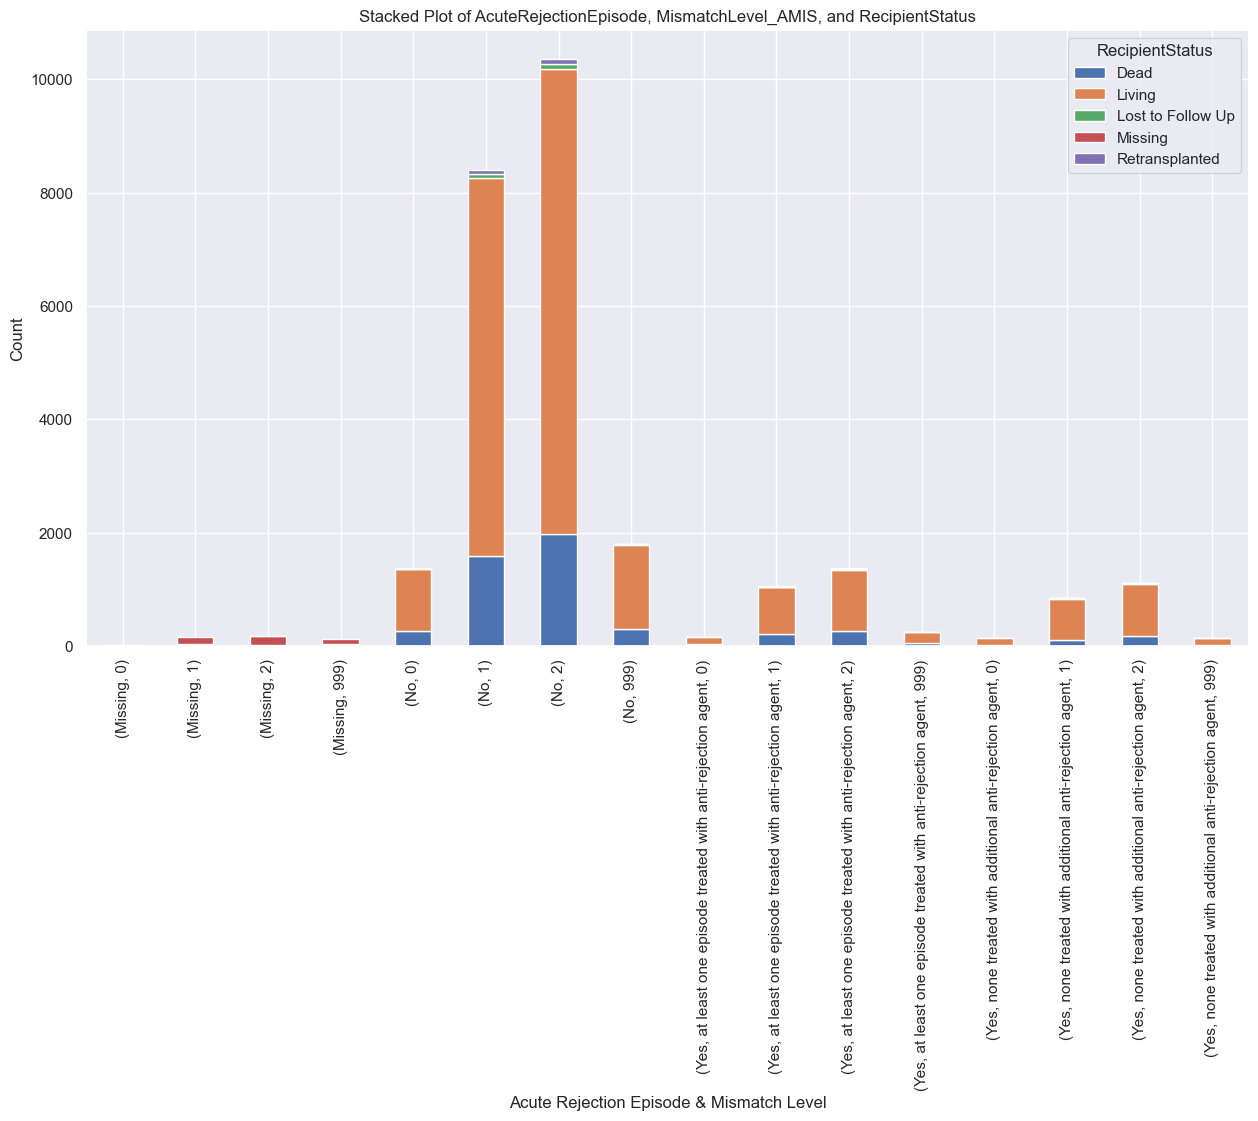

In [6]:
# contingency table
contingency_table = pd.crosstab(
    [df['AcuteRejectionEpisode'], df['MismatchLevel_AMIS']], 
    df['RecipientStatus']
)

# stacked bar plot
contingency_table.plot(kind='bar', stacked=True, figsize=(15, 8))

# add labels and title
plt.xlabel('Acute Rejection Episode & Mismatch Level')
plt.ylabel('Count')
plt.title('Stacked Plot of AcuteRejectionEpisode, MismatchLevel_AMIS, and RecipientStatus')

# show the plot
plt.show()

### Feature Information

In [7]:
# per year
uf.categoryContingency(df, 'ListingYear', 'RecipientStatus')

RecipientStatus,Dead,Living,Lost to Follow Up,Missing,Retransplanted,Row Total,Dead %,Living %
ListingYear,,,,,,,,
2011,664.0,1273.0,47.0,0.0,34.0,2018.0,32.903865,63.08226
2012,643.0,1438.0,32.0,0.0,35.0,2148.0,29.934823,66.945996
2013,620.0,1568.0,38.0,0.0,31.0,2257.0,27.470093,69.472751
2014,576.0,1791.0,26.0,0.0,26.0,2419.0,23.811492,74.038859
2015,512.0,1963.0,28.0,0.0,23.0,2526.0,20.2692,77.711797
2016,496.0,2112.0,13.0,0.0,17.0,2638.0,18.802123,80.060652
2017,436.0,2191.0,5.0,0.0,12.0,2644.0,16.490166,82.866868
2018,357.0,2363.0,4.0,3.0,24.0,2751.0,12.977099,85.896038
2019,358.0,2494.0,1.0,12.0,8.0,2873.0,12.460842,86.808214


In [8]:
numericCols = df_numeric.column.to_list()
print(sorted(numericCols))

['Age_CAN', 'Age_DON', 'Age_Listing_CAN', 'BMI_CAN', 'BMI_DON', 'BloodPH_DON', 'BloodUreaNitrogenLevel_DON', 'CPRA_Peak_CAN', 'CPRA_Recent_CAN', 'Class1PRA_TransplantPercentage_CAN', 'Class2PRA_TransplantPercentage_CAN', 'CreatinineListing_CAN', 'CreatinineTransplant_CAN', 'Creatinine_DON', 'DistanceFromDonorHospitaltoTXCenter', 'GraftLifeSpanDay', 'HeightCm_CAN', 'HeightCm_DON', 'Hematocrit_DON', 'HemodynamicsRegistration_CO_CAN', 'HemodynamicsRegistration_PA_DIA_CAN', 'HemodynamicsRegistration_PA_MN_CAN', 'HemodynamicsRegistration_PCW_CAN', 'HemodynamicsRegistration_SYS_CAN', 'HemodynamicsTransplant_CO_CAN', 'HemodynamicsTransplant_PA_DIA_CAN', 'HemodynamicsTransplant_PA_MN_CAN', 'HemodynamicsTransplant_PCW_CAN', 'HemodynamicsTransplant_SYS_CAN', 'IschemicTimeHour_DON', 'LV_EjectionFractionPercent_DON', 'LastFollowupNumber', 'LengthOfStay', 'Level_SGOT_ALT_DON', 'Level_SGOT_AST_DON', 'LungPO2_DON', 'LungPO2_FIO2_DON', 'OrganRecovery_PCO2_DON', 'TerminalTotalBilirubin_DON', 'TotalBili

In [9]:
nominalCols = df_nominal.column.to_list()
print(sorted(nominalCols))

['AirwayDehiscencePostTransplant', 'AllocationType_DON', 'AntiHypertensive_DON', 'AntibodyResultHBSAB_DON', 'AntibodyResultRPR_VDRL_DON', 'Antibody_HEP_C_DON', 'AntigenBW4_CAN', 'AntigenBW6_CAN', 'AntigenC1_CAN', 'AntigenC2_CAN', 'AntigenDA1_DON', 'AntigenDA2_DON', 'AntigenDB1_DON', 'AntigenDB2_DON', 'AntigenDQ1_CAN', 'AntigenDQ2_CAN', 'AntigenDR1_DON', 'AntigenDR2_DON', 'AntigenDR51_2_CAN', 'AntigenDR51_CAN', 'AntigenDR52_2_CAN', 'AntigenDR52_CAN', 'AntigenDR53_2_CAN', 'AntigenDR53_CAN', 'AntigenRA1_CAN', 'AntigenRA2_CAN', 'AntigenRB1_CAN', 'AntigenRB2_CAN', 'AntigenRDR1_CAN', 'AntigenRDR2_CAN', 'ArginnieManagement_DON', 'Biopsy_DON', 'BloodGroup_CAN', 'BloodGroup_DON', 'BloodInfectionSource_DON', 'BronchoscopyLeft_DON', 'BronchoscopyRight_DON', 'CMVStatus_Transplant_CAN', 'CMV_IGG_Transplant_CAN', 'CMV_IGM_Transplant_CAN', 'CancerExtraCranial_DON', 'CancerHistory_DON', 'CancerIntraCranial_DON', 'CancerSkin_DON', 'CardiacArrest_DON', 'CauseOfDeath_DON', 'CerebroVascularDisease_CAN', '

In [10]:
ordinalCols = df_ordinal.column.to_list()
print(sorted(ordinalCols))

['AcuteRejectionEpisode', 'BloodGroupMatchLevel', 'CigaretteAbstinence_CAN', 'DiabetesHistory_DON', 'DiabetesType_CAN', 'FunctionalStatusFollowUp', 'FunctionalStatusRegistration_CAN', 'FunctionalStatusTransplant_CAN', 'MedicalConditionTransplant_CAN', 'MismatchLevel_AMIS', 'MismatchLevel_BMIS', 'MismatchLevel_DRMIS', 'MismatchLevel_HLMIS', 'PreviousTransplantNumber_CAN', 'TransfusionNumber_DON']


In [12]:
objectCols = df_object.column.to_list()
print(sorted(objectCols))

['CancerSite_DON', 'DialysisTypeRegistration_CAN', 'OtherMedsText1_DON', 'OtherMedsText2_DON', 'OtherMedsText3_DON', 'PrimaryPaymentRegistration_CAN', 'PrimaryPaymentTransplant_CAN', 'VentricularDeviceBrandListing_CAN', 'VentricularDeviceBrandTransplant_CAN', 'VentricularDeviceTypeListing_CAN', 'VentricularDeviceTypeTransplant_CAN']


### Word Cloud Plot

#### User Function(s)

In [13]:
# import library
from wordcloud import WordCloud

# function to split and clean medications
def split_and_clean(x):
    if pd.isna(x):
        return []
    return [med.strip().upper() for med in str(x).split(',')]


def wordFreqPlot(data, txt, flag=False):
    """
    Word Cloud Plot combine multiple Text Features
    """
    # combine the columns
    data['CombinedMeds'] = data[txt].apply(lambda row: 
        list(sum([split_and_clean(cell) for cell in row if pd.notna(cell)], [])), axis=1)
    
    # convert the list to a comma-separated string
    data['CombinedMeds'] = data['CombinedMeds'].apply(lambda x: ', '.join(sorted(x)) if x else None)

    #
    if flag:
        # combine all medications into a single string
        text = ' '.join(df['CombinedMeds'].dropna().astype(str))
        
        # preprocess text: Convert to upper case and remove duplicates
        text = ' '.join(set(word.upper() for word in text.split(',')))
    
        # Create and generate a word cloud image
        wordcloud = WordCloud(width=1200, height=800, background_color='white').generate(text)
        
        # display the generated image
        plt.figure(figsize=(16, 8))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f"Combine {len(txt)} Text Columns **{txt}** Word Cloud \n", fontsize=12)
        plt.tight_layout(pad=0)
        plt.show()
    else:
        return  data['CombinedMeds']

#### Word Clouds

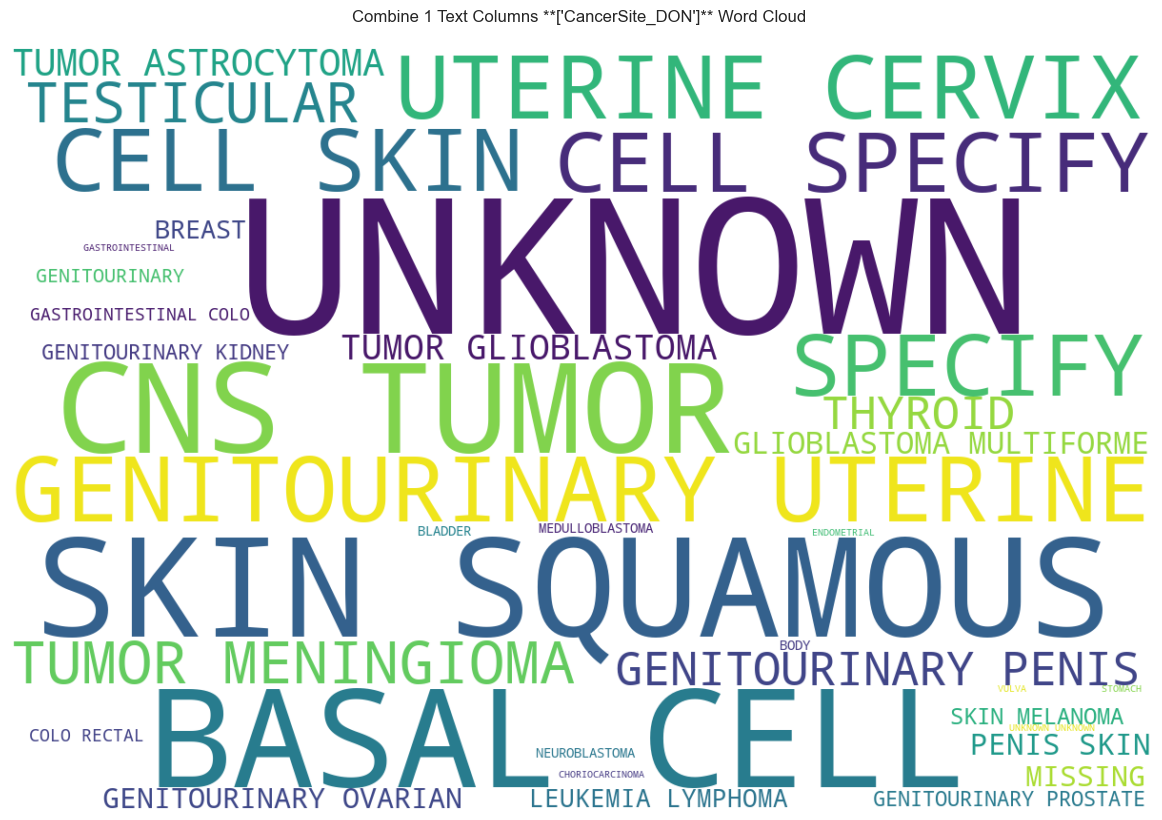

In [14]:
# initialize list
txtCol = ['CancerSite_DON']
# plot
wordFreqPlot(df, txtCol, flag=True)

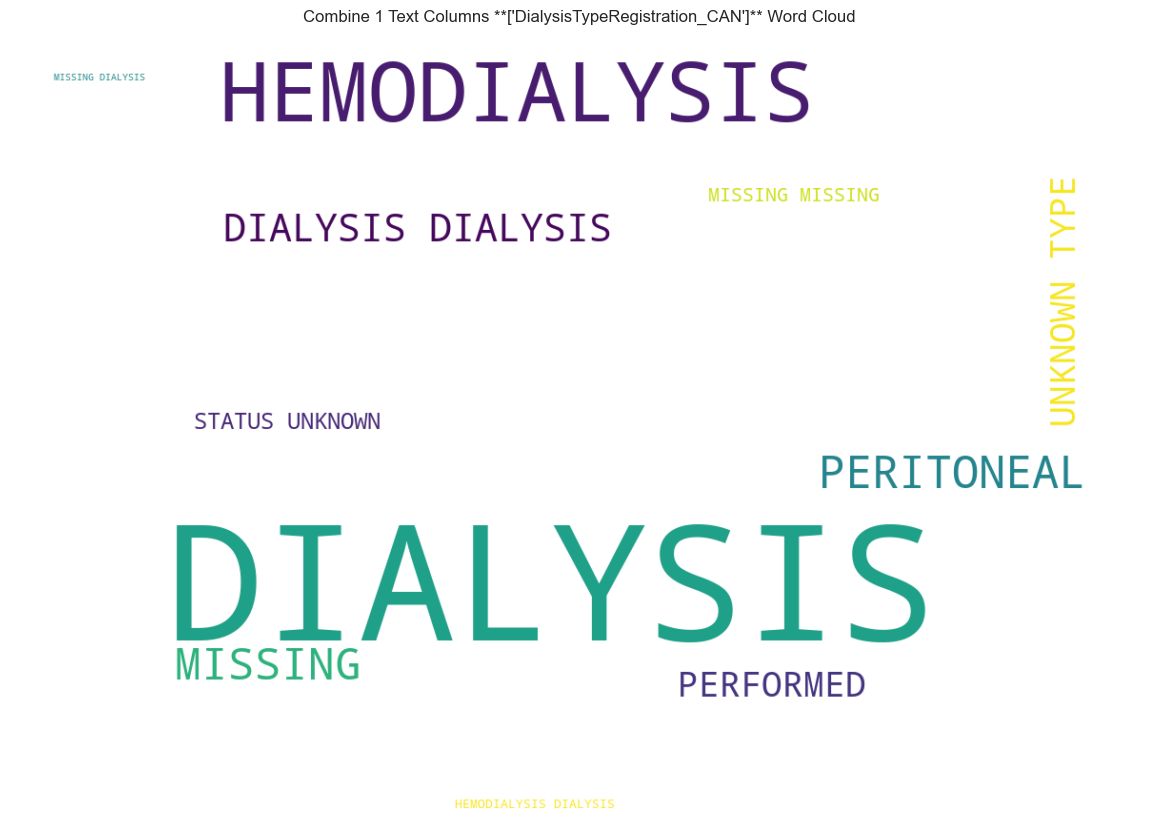

In [15]:
# initialize list
txtCol = ['DialysisTypeRegistration_CAN']
# plot
wordFreqPlot(df, txtCol, flag=True)

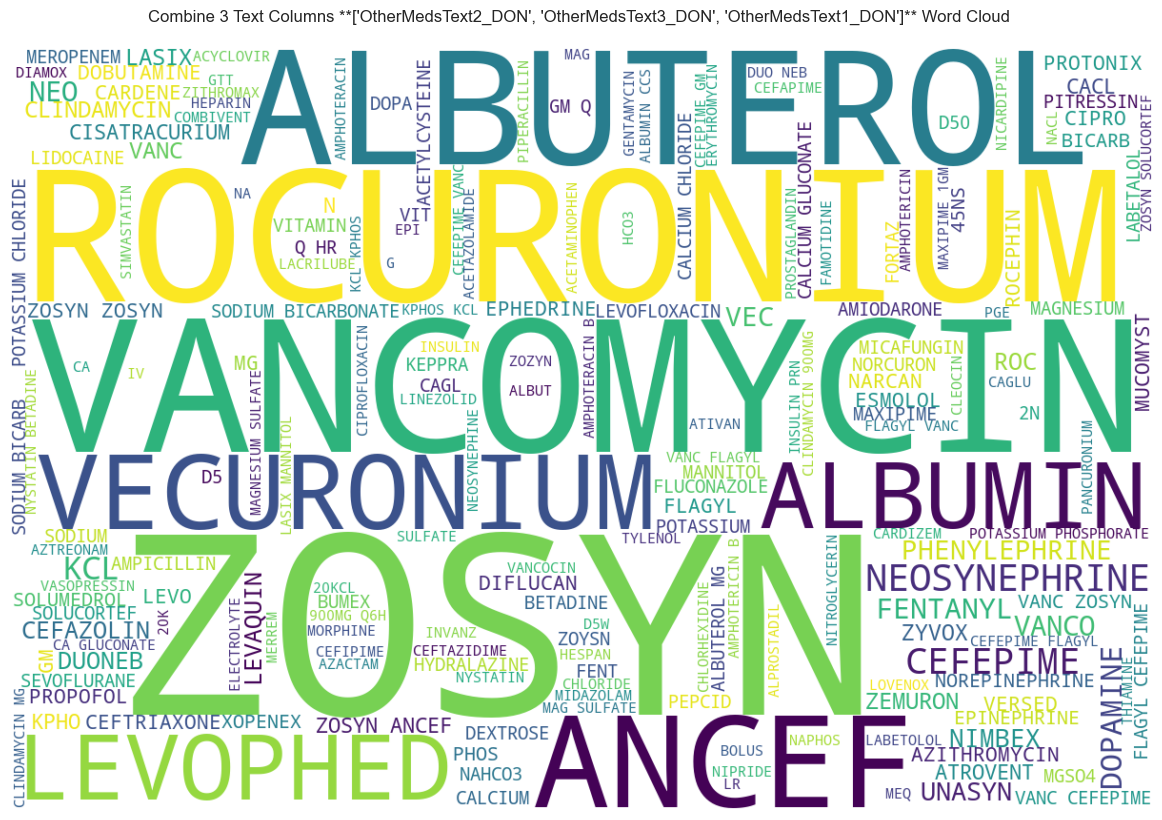

In [16]:
# initialize list
txtCol = ['OtherMedsText2_DON', 'OtherMedsText3_DON', 'OtherMedsText1_DON']
# plot
wordFreqPlot(df, txtCol, flag=True)

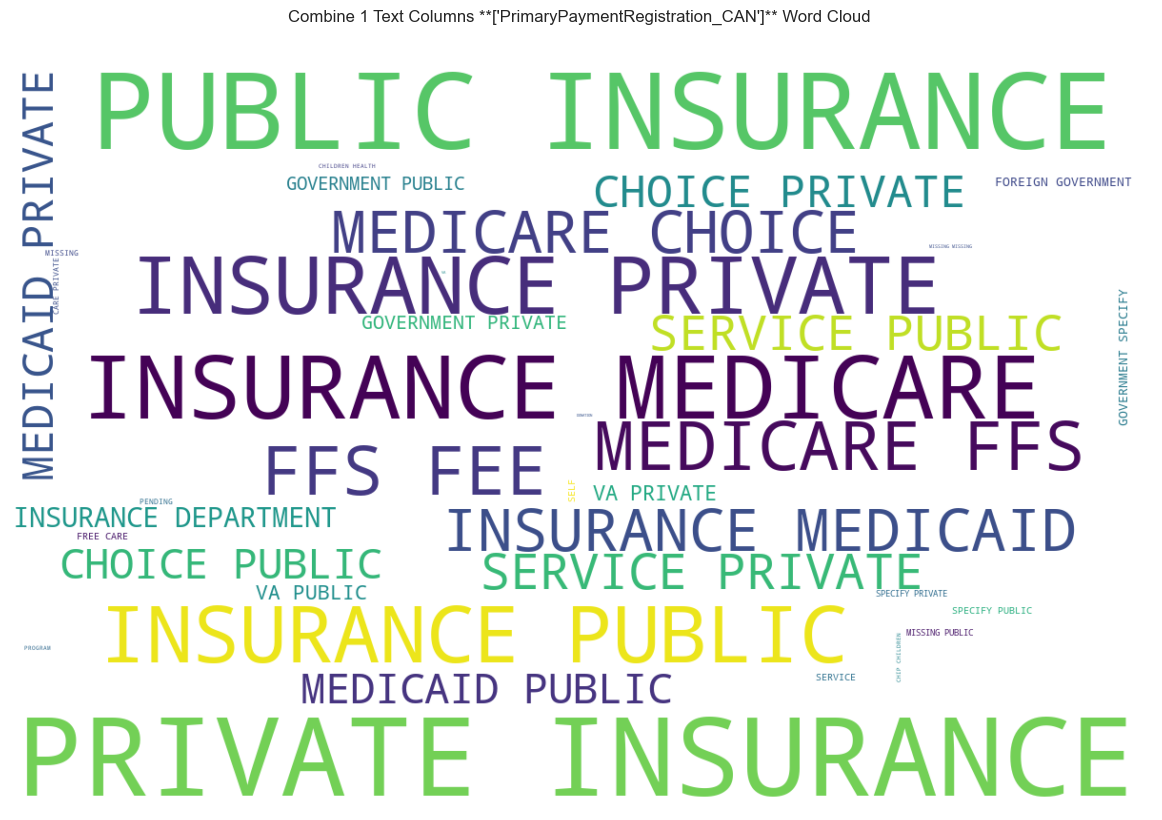

In [17]:
# initialize list
txtCol = ['PrimaryPaymentRegistration_CAN']
# plot
wordFreqPlot(df, txtCol, flag=True)

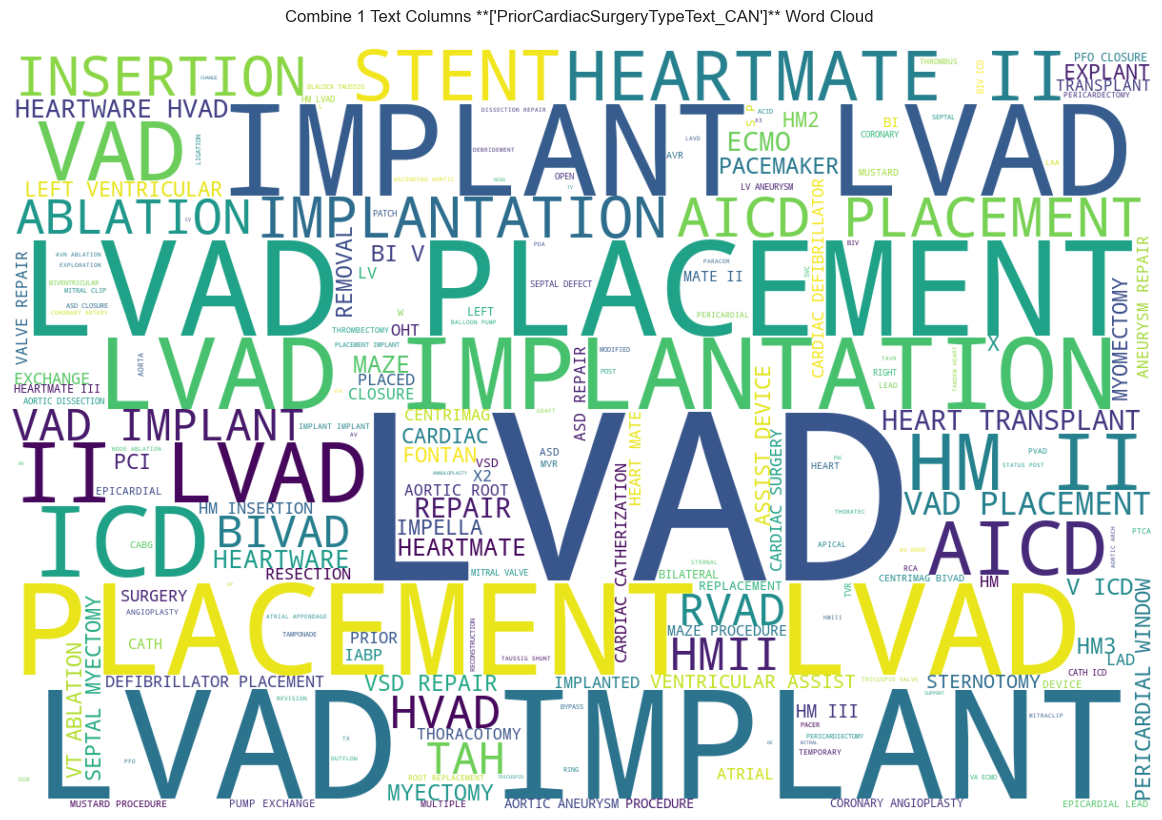

In [18]:
# initialize list
txtCol = ['PriorCardiacSurgeryTypeText_CAN']
# plot
wordFreqPlot(df, txtCol, flag=True)

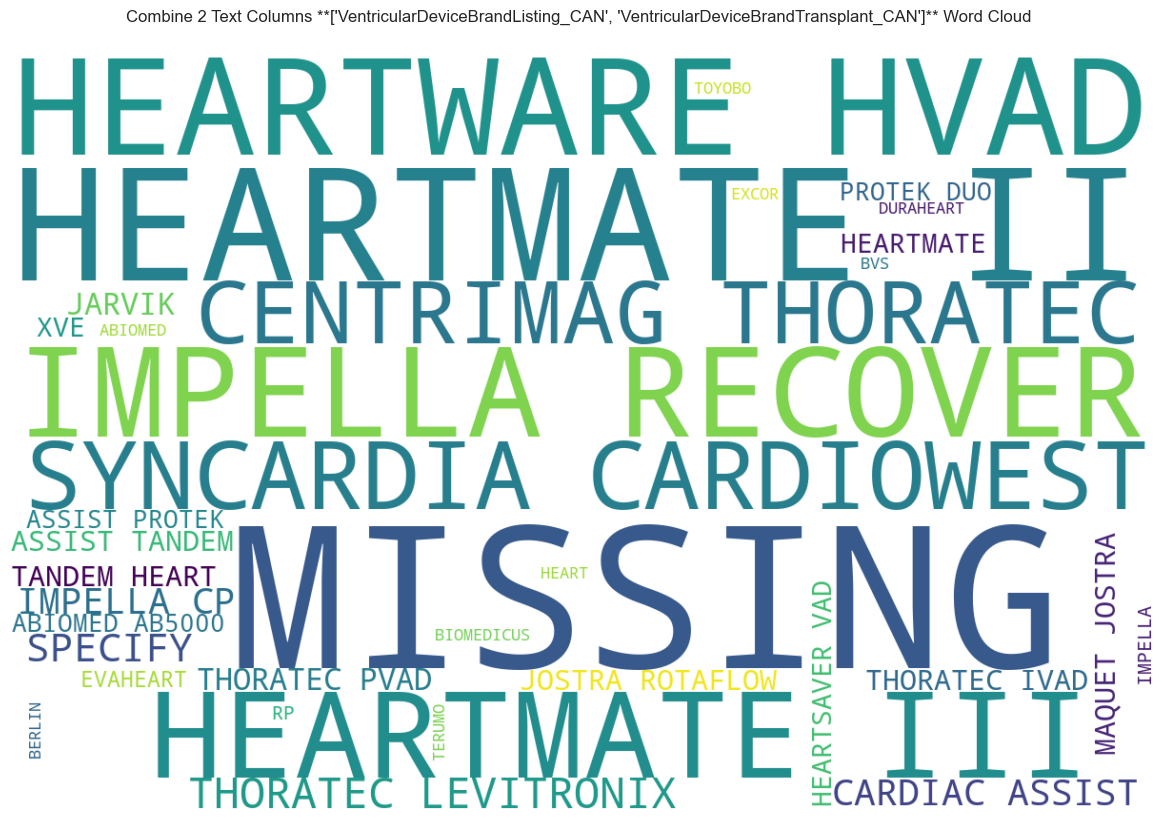

In [21]:
# initialize list
txtCol = ['VentricularDeviceBrandListing_CAN', 'VentricularDeviceBrandTransplant_CAN']
# plot
wordFreqPlot(df, txtCol, flag=True)

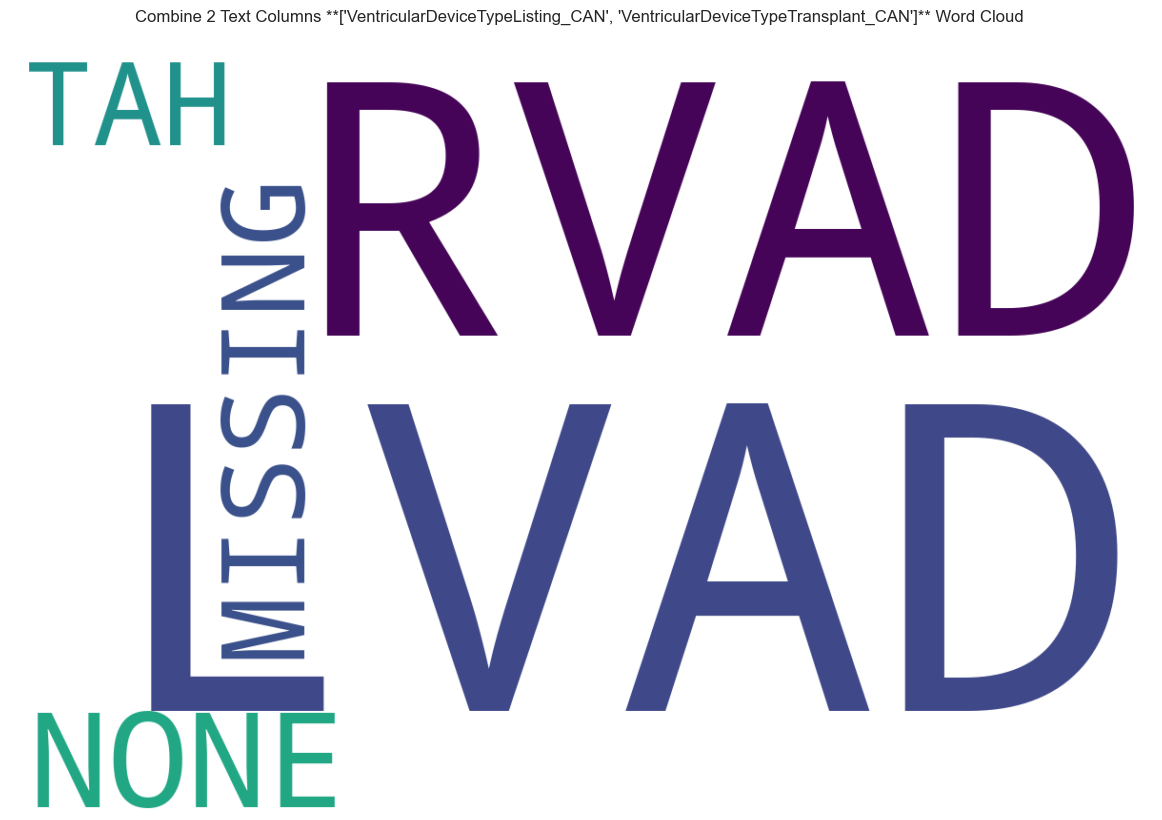

In [22]:
# initialize list
txtCol = ['VentricularDeviceTypeListing_CAN', 'VentricularDeviceTypeTransplant_CAN']
# plot
wordFreqPlot(df, txtCol, flag=True)

### Ordinal

In [20]:
for col in ordinalCols:
    if col not in labelCols:
        print(uf.categoryContingency(df, col, 'RecipientStatus').to_string())
        print("\n")

RecipientStatus         Dead   Living  Lost to Follow Up  Missing  Retransplanted  Row Total     Dead %   Living %
BloodGroupMatchLevel                                                                                              
Compatible             732.0   3192.0               23.0     48.0            35.0     4030.0  18.163772  79.205955
Identical             4301.0  18452.0              171.0    342.0           197.0    23463.0  18.330989   78.64297
Incompatible             0.0      1.0                0.0      0.0             0.0        1.0        0.0      100.0
Column Total          5033.0  21645.0              194.0    390.0           232.0    27494.0                      


RecipientStatus       Dead   Living  Lost to Follow Up  Missing  Retransplanted  Row Total     Dead %   Living %
MismatchLevel_AMIS                                                                                              
0                    324.0   1333.0                5.0     20.0            20.0   

### Nominal

In [21]:
for col in nominalCols:
    if col not in labelCols:
        print(uf.categoryContingency(df, col, 'RecipientStatus').to_string())
        print("\n")

RecipientStatus    Dead   Living  Lost to Follow Up  Missing  Retransplanted  Row Total     Dead %   Living %
BloodGroup_CAN                                                                                               
A                1980.0   8650.0               68.0    134.0            86.0    10918.0   18.13519  79.226965
A1                 12.0     53.0                0.0      2.0             2.0       69.0  17.391304  76.811594
A1B                 0.0      5.0                0.0      0.0             0.0        5.0        0.0      100.0
A2                  0.0      7.0                0.0      0.0             0.0        7.0        0.0      100.0
A2B                 1.0      3.0                0.0      0.0             0.0        4.0       25.0       75.0
AB                302.0   1210.0               14.0     23.0            13.0     1562.0  19.334187  77.464789
B                 776.0   3328.0               28.0     62.0            48.0     4242.0  18.293258   78.45356
O         

### Numeric

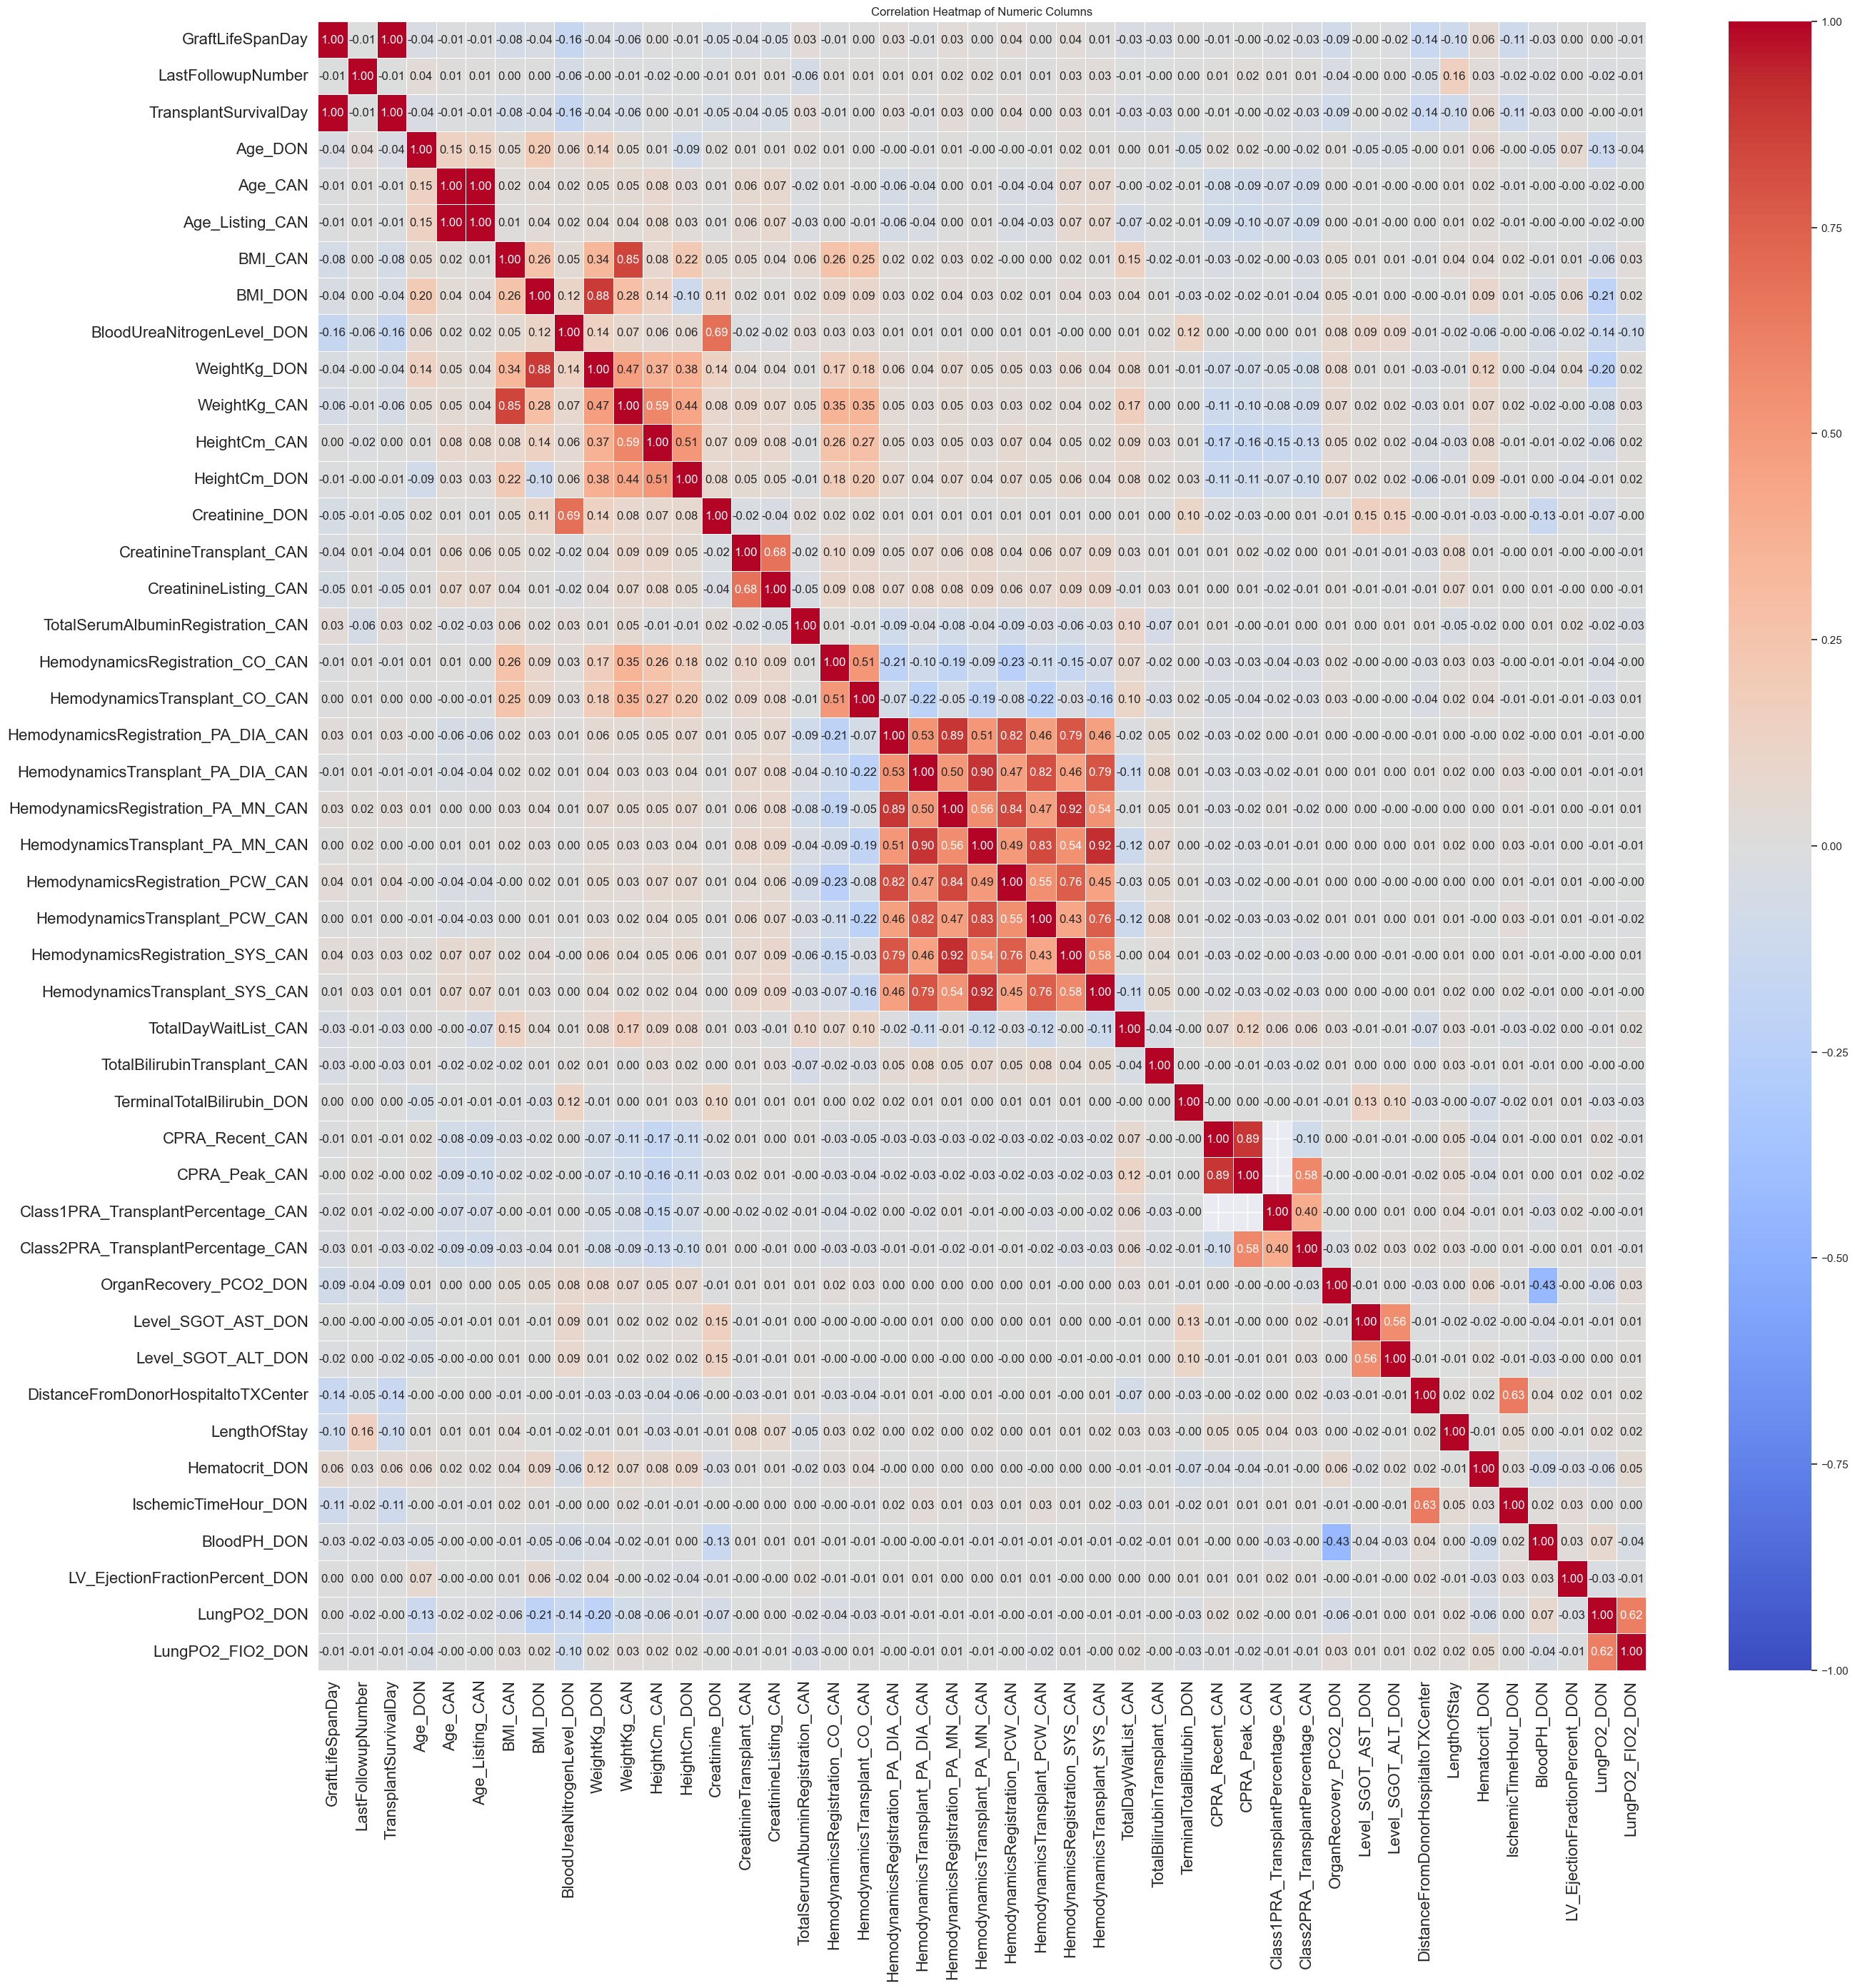

In [30]:
# calculate the correlation matrix
corr_matrix = df[numericCols].corr()

# plotting the heatmap
plt.figure(figsize=(30, 30))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numeric Columns')
# adjusting the font size of the ticks
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()